## Multidimensional LSTM-based Autoencoder for Sequential Metrics

### 1. Environment Setup & Library Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

# Configure random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### 2. Synthesize Multidimensional Sequential Training Arrays
We will synthesize a 3-dimensional temporal signal representing multiple correlated structural metrics.

In [7]:
num_samples = 800
timesteps = 40
features = 3

def generate_multidimensional_data(samples, steps, dims):
    t = np.linspace(0, 50, steps)
    data = []
    for _ in range(samples):
        # Base frequencies and phase offsets for correlated channels
        freq1, freq2 = np.random.uniform(0.1, 0.3), np.random.uniform(0.2, 0.4)
        phase = np.random.uniform(0, np.pi)

        ch1 = np.sin(t * freq1 + phase)
        ch2 = np.cos(t * freq2 + phase) * 0.8
        ch3 = (ch1 + ch2) * 0.5 + np.random.normal(0, 0.05, size=steps) # Correlated mixture

        sample = np.stack([ch1, ch2, ch3], axis=-1)
        data.append(sample)
    return np.array(data)

X_data = generate_multidimensional_data(num_samples, timesteps, features)
print(f"Dataset Shape: {X_data.shape} (Samples, Timesteps, Features)")

Dataset Shape: (800, 40, 3) (Samples, Timesteps, Features)


### 3. Build the Model Architecture
We design an Encoder-Decoder structure that compresses the sequence to a compact bottleneck state and reconstructs it.

In [8]:
latent_dimension = 16

# Encoder network
inputs = Input(shape=(timesteps, features))
encoder = LSTM(32, activation='tanh', return_sequences=False)(inputs)
bottleneck = Dense(latent_dimension, activation='relu')(encoder)

# Decoder network
decoder_input = RepeatVector(timesteps)(bottleneck)
decoder_lstm = LSTM(32, activation='tanh', return_sequences=True)(decoder_input)
outputs = TimeDistributed(Dense(features))(decoder_lstm)

# Define the full autoencoder model
autoencoder = Model(inputs, outputs)
print("Model constructed successfully.")

Model constructed successfully.


### 4. Model Configuration & Diagnostic Summary

In [9]:
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 40, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 40, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 40, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 40, 3)          │            99 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,507 (44.95 KB)

 Trainable params: 11,507 (44.95 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Perform Unsupervised Model Training
We train the model using `X_data` as both input and target output.

Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.3299 - val_loss: 0.3278
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3238 - val_loss: 0.3166
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.3075 - val_loss: 0.2997
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2955 - val_loss: 0.2911
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2876 - val_loss: 0.2832
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2765 - val_loss: 0.2698
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2599 - val_loss: 0.2494
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2382 - val_loss: 0.2235
Epoch 9/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2136 - val_loss: 0.2021
Epoch 10/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1870 - val_loss: 0.1636
Epoch 11/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1546 - val_loss: 0.1475
Epoch 12/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1

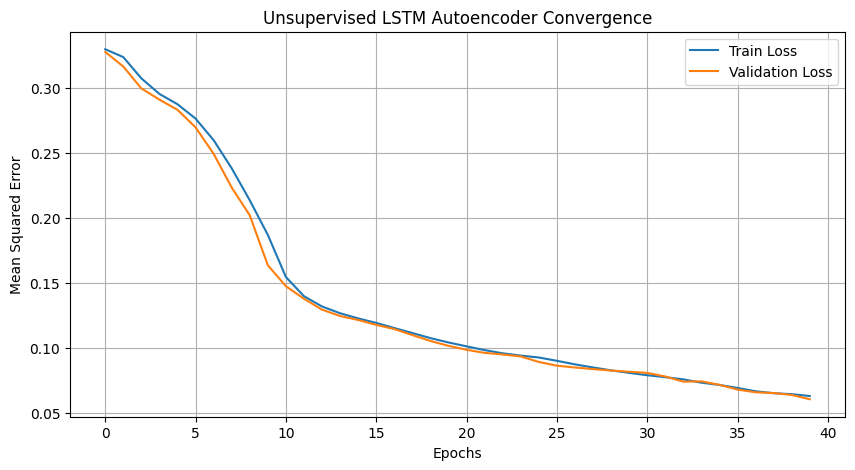

In [10]:
history = autoencoder.fit(
    X_data, X_data,
    epochs=40,
    batch_size=32,
    validation_split=0.25,
    verbose=1
)

# Plot loss trends
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Unsupervised LSTM Autoencoder Convergence')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

### 6. Verify Compression & Reconstruction

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


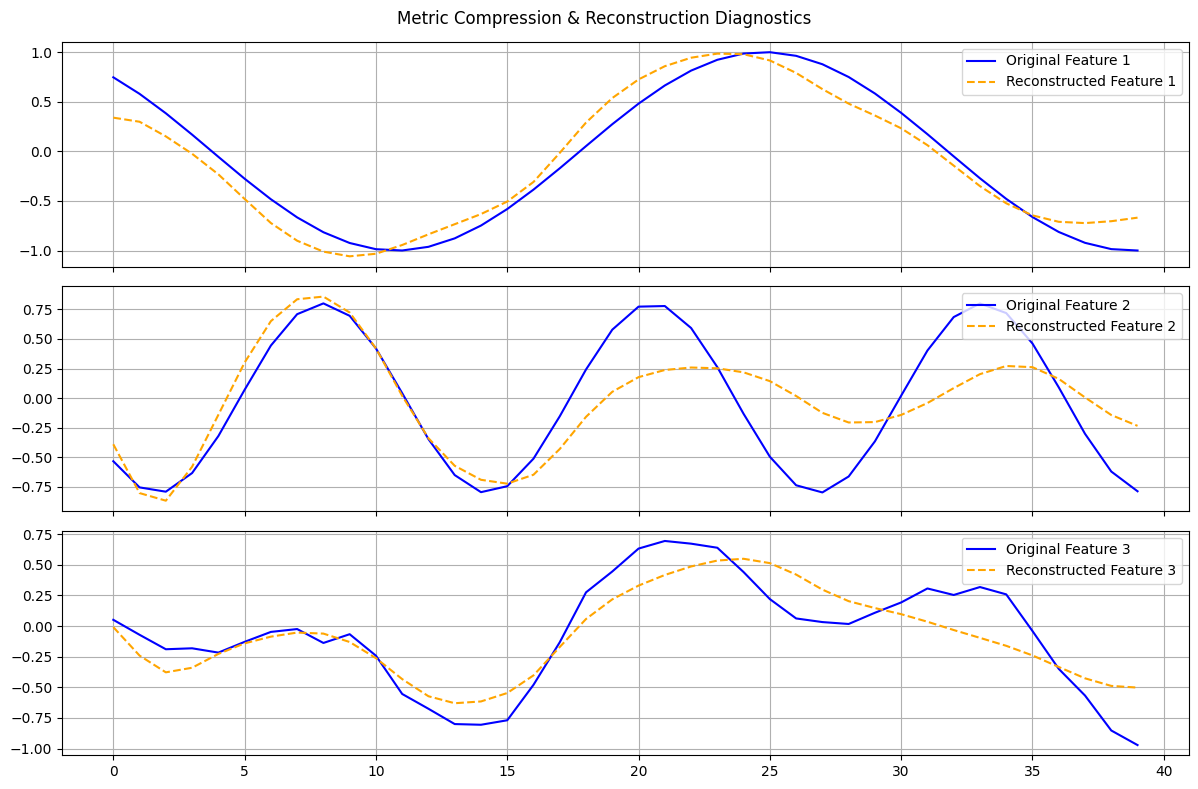

In [11]:
# Predict reconstructed metrics
reconstructed_data = autoencoder.predict(X_data)

# Plot reconstruction vs original for a sample
sample_idx = 0
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for d in range(features):
    axes[d].plot(X_data[sample_idx, :, d], label='Original Feature ' + str(d+1), color='blue')
    axes[d].plot(reconstructed_data[sample_idx, :, d], label='Reconstructed Feature ' + str(d+1), color='orange', linestyle='--')
    axes[d].legend()
    axes[d].grid(True)
plt.suptitle("Metric Compression & Reconstruction Diagnostics")
plt.tight_layout()
plt.show()

### 7. Evaluation: Compute and Display Mean Squared Error (MSE)

In [13]:
# Calculate the mean squared error between the original data and reconstructed data
mse_reconstruction = np.mean(np.power(X_data - reconstructed_data, 2))
print(f"Overall Reconstruction Mean Squared Error (MSE): {mse_reconstruction:.5f}")

Overall Reconstruction Mean Squared Error (MSE): 0.05959
